In [19]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, csr_matrix
from scipy.sparse.linalg import spsolve
from typing import Literal

class PipelineSegment:
    def __init__(self, length, diameter, position_start):
        self.length = length
        self.diameter = diameter
        self.position_start = position_start
        self.position_end = position_start + length
        self.area = np.pi * (diameter / 2) ** 2

class Pump:
    def __init__(self, position, delta_P):
        self.position = position
        self.delta_P = delta_P

class HeatExchanger:
    def __init__(self, position, heat_power, length=2.0):
        self.position = position
        self.heat_power = heat_power
        self.length = length  # длина зоны нагрева

class WaterConsumer:
    def __init__(self, position, consumption_rate):
        self.position = position
        self.consumption_rate = consumption_rate



In [20]:
class AdvancedPipelineSystem:
    def __init__(self):
        # Начальные условия
        self.initial_pressure = 3e5  # Па
        self.initial_flow_rate = 3e-3  # м³/с
        self.initial_temperature = 273+5  # К (5 °C)

        # Свойства жидкости
        self.density = 1000  # кг/м³
        self.specific_heat = 4186  # Дж/(кг·К)
        self.thermal_conductivity = 0.6  # Вт/(м·К)

        # Список сегментов трубы
        self.segments = [
            PipelineSegment(10, 0.065, 0),
            PipelineSegment(20, 0.065, 10),
            PipelineSegment(30, 0.065, 30),
            PipelineSegment(40, 0.050, 60)
        ]

        # Общая длина системы
        self.total_length = sum(seg.length for seg in self.segments)

        # Элементы системы
        self.pumps = [
            Pump(10, 8e4),
            Pump(45, 6e4)
        ]
        self.heat_exchangers = [
            HeatExchanger(15, 700e3, length=1.0),  # 15 кВт на 3 м
            # HeatExchanger(30, 25000, length=1.0)  # 25 кВт на 4 м
        ]
        self.consumers = [
            WaterConsumer(50, 0.5e-3),
            WaterConsumer(60, 0.5e-3)
        ]

        # Создание сетки
        self._create_grid()

    def _create_grid(self):
        """Создание неравномерной сетки"""
        total_cells = 100
        self.x = np.linspace(0, self.total_length, total_cells)
        self.dx = np.diff(self.x)

        self.cell_centers = (self.x[:-1] + self.x[1:]) / 2
        self.N = len(self.cell_centers)

        # Определение диаметра для каждой ячейки
        self.diameters = np.zeros(self.N)
        self.areas = np.zeros(self.N)

        for i, x_center in enumerate(self.cell_centers):
            for seg in self.segments:
                if seg.position_start <= x_center <= seg.position_end:
                    self.diameters[i] = seg.diameter
                    self.areas[i] = seg.area
            if self.areas[i] == 0:  # если не найден сегмент, берём предыдущий
                self.diameters[i] = self.diameters[i-1] if i > 0 else 0.1
                self.areas[i] = np.pi * (self.diameters[i]/2)**2

        # Инициализация параметров
        self.pressure = np.full(self.N, self.initial_pressure)
        self.temperature = np.full(self.N, self.initial_temperature)
        self.flow_rate = np.full(self.N, self.initial_flow_rate)
        self.velocity = self.flow_rate / self.areas

    def calculate_friction_loss(self, segment_idx):
        """Расчёт потерь на трение"""
        diameter = self.diameters[segment_idx]
        velocity = self.velocity[segment_idx]
        friction_factor = 0.02 * (0.1 / diameter)
        return friction_factor * self.dx[segment_idx] / diameter * self.density * velocity**2 / 2


    def apply_pumps(self):
        """Применение насосов"""
        for pump in self.pumps:
            cell_idx = np.argmin(np.abs(self.cell_centers - pump.position))
            if 0 <= cell_idx < self.N:
                self.pressure[cell_idx] += pump.delta_P


    def apply_heat_exchangers(self):
        """Нагрев только в одной ближайшей точке к позиции теплообменника"""
        heat_sources = np.zeros(self.N)

        for heater in self.heat_exchangers:
            cell_idx = np.argmin(np.abs(self.cell_centers - heater.position))

            if 0 <= cell_idx < self.N:
                mass_flow = self.density * self.flow_rate[cell_idx]
                if mass_flow > 0:
                    delta_T = heater.heat_power / (mass_flow * self.specific_heat)
                    heat_sources[cell_idx] = delta_T

        return heat_sources


    def heatloss_pipe_unit_W(self,
            diameter_m,
            temperature_K,          
            thickness_m: float = 0.025,
            isolation_lambda: float = 0.05,
            material: str = 'steel',
            ambient_temp = 293,
    ) -> float:
        """
        Расчёт нормативных потерь тепла на метр трубы для каждой ячейки.
        """

        if temperature_K > ambient_temp:
            temp_diff = temperature_K - ambient_temp
            isolation_d2 = diameter_m + (2 * thickness_m)

            # Коэффициент теплопередачи в зависимости от материала
            K = 1.2 if material == "steel" else 1.7
            alpha_is = 10  # коэффициент теплоотдачи изоляции, Вт/(м²·К)

            # Термическое сопротивление изоляции
            Ris = ((1 / (2 * np.pi * isolation_lambda))) * np.log(isolation_d2 / (diameter_m))
            # Термическое сопротивление конвективного теплообмена
            Ris_L = 1 / (np.pi * isolation_d2 * alpha_is)

            # Нормативные потери тепла на метр длины
            cooling_losses = K * temp_diff / (Ris + Ris_L)
        
        else: 
            cooling_losses = 0

        return cooling_losses  # Вт/м


    def solve_temperature_distribution(self, heat_sources):
        """Решение уравнения теплопереноса методом конечных объёмов с нормативным расчётом потерь"""
        # Начинаем с начальной температуры
        self.temperature = np.full(self.N, self.initial_temperature)
        ambient_temp = 293  # К (20 °C)

        # Рассчитываем потери тепла для каждой ячейки (нормативный расчёт)

        # Последовательный расчёт по ячейкам — «движение» воды
        current_temp = self.initial_temperature

        for i in range(self.N):
            # 1. Конвективный перенос: берём температуру из предыдущей ячейки
            # Для первой ячейки — начальная температура
            if i > 0:
                current_temp = self.temperature[i-1]

            # 2. Нагрев в этой ячейке (если есть теплообменник)
            if heat_sources[i] > 0:
                current_temp += heat_sources[i]

            # 3. Охлаждение на длине ячейки
            cell_length = self.dx[i] if i < len(self.dx) else self.dx[-1]
            heat_loss_in_cell = self.heatloss_pipe_unit_W(diameter_m=self.diameters[i], temperature_K=current_temp) * cell_length  # Вт
            print(f'heat_loss_in_cell {heat_loss_in_cell}')

            # Массовый расход в этой ячейке
            mass_flow = self.density * self.flow_rate[i]
            if mass_flow > 0:
                # Потери температуры из‑за охлаждения (ΔT = Q_loss / (m_dot * c_p))
                delta_T_cool = heat_loss_in_cell / (mass_flow * self.specific_heat)
                current_temp -= delta_T_cool
                # print(f'current_temp {current_temp} - delta_T_cool {delta_T_cool}')

            # 4. Гарантируем, что температура не опустится ниже окружающей среды
            if current_temp < ambient_temp:
                current_temp = ambient_temp

            # 5. Сохраняем температуру для этой ячейки
            self.temperature[i] = current_temp



    def apply_consumers(self):
        """Применение потребителей"""
        for consumer in self.consumers:
            cell_idx = np.argmin(np.abs(self.cell_centers - consumer.position))
            if 0 <= cell_idx < self.N:
                # Уменьшаем расход после потребителя
                self.flow_rate[cell_idx:] -= consumer.consumption_rate
                # Пересчитываем скорость
                self.velocity[cell_idx:] = self.flow_rate[cell_idx:] / self.areas[cell_idx:]



    def solve_pressure_distribution(self):
        """Решение уравнения давления"""
        A = diags([-1, 2, -1], [-1, 0, 1], shape=(self.N, self.N), format='csr')
        b = np.zeros(self.N)

        # Граничные условия
        b[0] = self.initial_pressure  # давление на входе
        b[-1] = 1e5  # давление на выходе (атмосферное)

        # Учёт потерь на трение
        friction_losses = np.array([self.calculate_friction_loss(i) for i in range(self.N)])
        b -= friction_losses

        self.pressure = spsolve(A, b)

    def run_simulation(self):
        """Запуск полного расчёта системы с последовательным теплопереносом"""
        # Применяем насосы
        self.apply_pumps()

        # Применяем потребителей (влияют на расход и скорость)
        self.apply_consumers()
        # Решаем уравнение давления
        self.solve_pressure_distribution()
        # Пересчитываем скорость с учётом обновлённого давления
        self.velocity = self.flow_rate / self.areas
        # Применяем теплообменники и получаем массив источников тепла
        heat_sources = self.apply_heat_exchangers()
        # Решаем уравнение температуры с учётом последовательного теплопереноса
        self.solve_temperature_distribution(heat_sources)


    def plot_results(self):
        """Визуализация результатов с маркировкой элементов"""
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12))

        # Давление
        ax1.plot(self.cell_centers, self.pressure / 1e5, 'b-', linewidth=2, label='Давление')
        ax1.set_ylabel('Давление, бар')
        ax1.set_title('Распределение давления по длине трубопровода')
        ax1.grid(True)

        # Температура
        ax2.plot(self.cell_centers, self.temperature - 273.15, 'r-', linewidth=2, label='Температура')
        ax2.set_ylabel('Температура, °C')
        ax2.set_title('Распределение температуры по длине трубопровода')
        ax2.grid(True)

        # Расход
        ax3.plot(self.cell_centers, self.flow_rate * 1e3, 'g-', linewidth=2, label='Расход')
        ax3.set_ylabel('Расход, кг/с')
        ax3.set_title('Распределение расхода по длине трубопровода')
        ax3.grid(True)

        # Скорость
        ax4.plot(self.cell_centers, self.velocity, 'purple', linewidth=2, label='Скорость')
        ax4.set_xlabel('Координата, м')
        ax4.set_ylabel('Скорость, м/с')
        ax4.set_title('Распределение скорости по длине трубопровода')
        ax4.grid(True)

        # Маркировка элементов на всех графиках
        for pump in self.pumps:
            ax1.axvline(x=pump.position, color='blue', linestyle='--', alpha=0.7, label='Насос' if pump == self.pumps[0] else "")
            ax2.axvline(x=pump.position, color='blue', linestyle='--', alpha=0.7)
            ax3.axvline(x=pump.position, color='blue', linestyle='--', alpha=0.7)
            ax4.axvline(x=pump.position, color='blue', linestyle='--', alpha=0.7)

        for heater in self.heat_exchangers:
            start = heater.position
            end = heater.position + heater.length
            ax1.axvspan(start, end, color='red', alpha=0.1)
            ax2.axvspan(start, end, color='red', alpha=0.1, label='Теплообменник' if heater == self.heat_exchangers[0] else "")
            ax3.axvspan(start, end, color='red', alpha=0.1)
            ax4.axvspan(start, end, color='red', alpha=0.1)

        for consumer in self.consumers:
            ax1.axvline(x=consumer.position, color='green', linestyle='--', alpha=0.7, label='Потребитель' if consumer == self.consumers[0] else "")
            ax2.axvline(x=consumer.position, color='green', linestyle='--', alpha=0.7)
            ax3.axvline(x=consumer.position, color='green', linestyle='--', alpha=0.7)
            ax4.axvline(x=consumer.position, color='green', linestyle='--', alpha=0.7)

        # Добавляем легенды
        ax1.legend()
        ax2.legend()
        ax3.legend()
        ax4.legend()

        plt.tight_layout()
        plt.show()

    def print_system_summary(self):
        """Вывод сводки по системе"""
        print("=" * 60)
        print("СВОДКА ПО СИСТЕМЕ ТРУБОПРОВОДА")
        print("=" * 60)

        print(f"Общая длина системы: {self.total_length:.1f} м")
        print(f"Начальное давление: {self.initial_pressure/1e5:.1f} бар")
        print(f"Конечное давление: {self.pressure[-1]/1e5:.1f} бар")
        print(f"Начальный расход: {self.initial_flow_rate:.4f} м³/с")
        print(f"Конечный расход: {self.flow_rate[-1]:.4f} м³/с")
        print(f"Начальная температура: {self.initial_temperature-273.15:.1f} °C")
        print(f"Конечная температура: {self.temperature[-1]-273.15:.1f} °C")

        print("\nСЕГМЕНТЫ ТРУБЫ:")
        for i, seg in enumerate(self.segments):
            print(f"  Сегмент {i+1}: {seg.length:.1f} м, D={seg.diameter*100:.0f} см, "
                  f"S={seg.area:.4f} м²")

        print("\nНАСОСЫ:")
        for i, pump in enumerate(self.pumps):
            print(f"  Насос {i+1} на {pump.position} м: +{pump.delta_P/1e4:.1f} кПа")

        print("\nТЕПЛООБМЕННИКИ:")
        for i, heater in enumerate(self.heat_exchangers):
            print(f"  Теплообменник {i+1} на {heater.position}–{heater.position+heater.length} м: "
                  f"{heater.heat_power/1000:.1f} кВт")

        print("\nПОТРЕБИТЕЛИ:")
        for i, consumer in enumerate(self.consumers):
            print(f"  Потребитель {i+1} на {consumer.position} м: -{consumer.consumption_rate:.4f} м³/с")

        print("=" * 60)




heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 0.0
heat_loss_in_cell 32.28321783759276
heat_loss_in_cell 31.85385104035278
heat_loss_in_cell 31.27469011234636
heat_loss_in_cell 30.695529184339946
heat_loss_in_cell 30.116368256333534
heat_loss_in_cell 29.537207328327117
heat_loss_in_cell 28.958046400320704
heat_loss_in_cell 28.37888547231429
heat_loss_in_cell 27.799724544307875
heat_loss_in_cell 27.220563616301366
heat_loss_in_cell 26.64140268829505
heat_loss_in_cell 26.062241760288632
heat_loss_in_cell 25.48308083228222
heat_loss_in_cell 24.90391990427581
heat_loss_in_cell 24.32475897626939
heat_loss_in_cell 23.745598048262977
heat_loss_in_cell 23.166437120256564
heat_loss_in_cell 22.587276192250147
heat_loss_in_cell 22.0081152642437

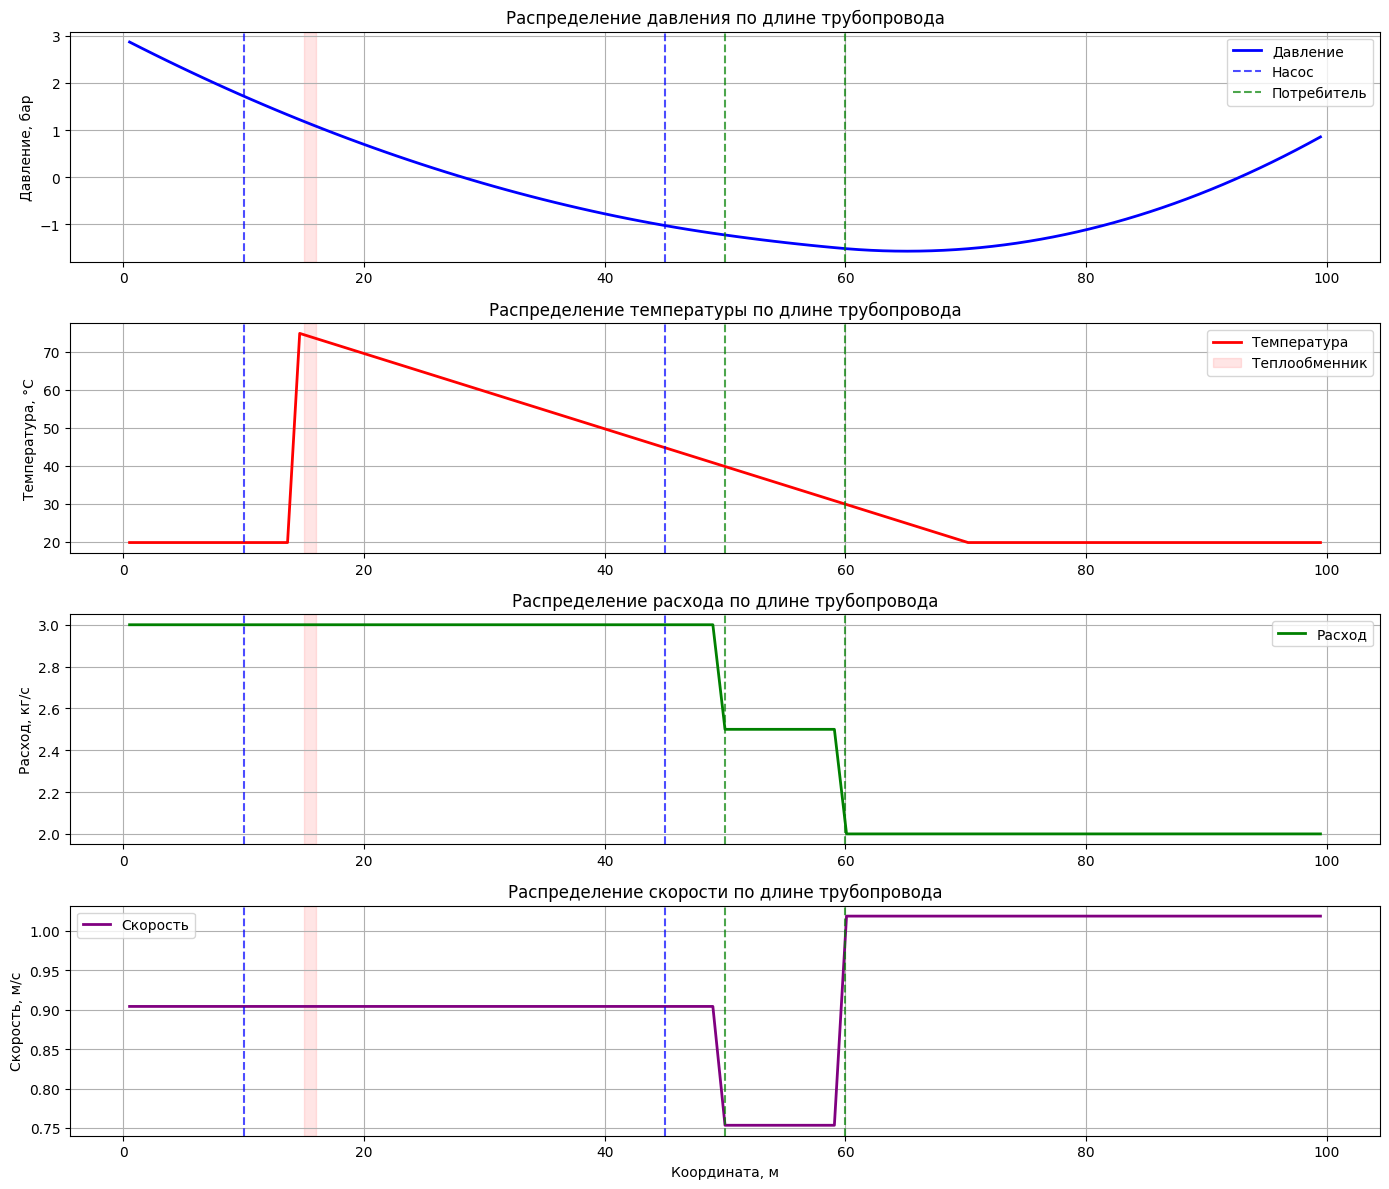

In [21]:
system = AdvancedPipelineSystem()

# Запуск расчёта
system.run_simulation()

# Вывод сводки
system.print_system_summary()

# Визуализация результатов
system.plot_results()
